# QSVT Sign Function and Spectral Projectors

This notebook demonstrates one of the most important matrix-function
applications of QSVT:

approximating the sign function and building spectral projectors.

## Variable definitions

- $A$ is a Hermitian matrix and $x$ is one of its normalized eigenvalues.
- $\operatorname{sign}(x)$ is $-1$, $0$, or $1$ according to the sign of $x$.
- $\operatorname{sign}(A)$ applies the scalar sign function to the eigenvalues of $A$.
- With $I$ the identity on the same space, $P_+=(I+\operatorname{sign}(A))/2$ and $P_-=(I-\operatorname{sign}(A))/2$ are the positive- and negative-spectrum projectors.

## Notebook guide

- **Learning objective:** construct sign approximations and spectral projectors.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](06_QSVT_Matrix_Functions_Powers_and_Roots.ipynb) · [next](08_QSVT_Design_and_Presets.ipynb).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.polynomials import (
    chebyshev_t,
    polynomial_parity,
    is_bounded_on_interval,
)

from qsvt.matrices import rotation

from qsvt.spectral import (
    eigh_hermitian,
    positive_projector_from_sign,
    negative_projector_from_sign,
)

## 1. Chebyshev polynomials as sign approximations

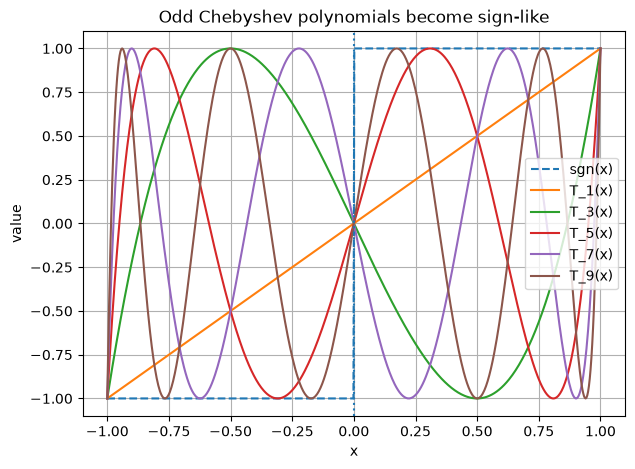

In [2]:
x = np.linspace(-1, 1, 600)

plt.figure(figsize=(7, 5))

plt.plot(x, np.sign(x), "--", label="sgn(x)")

for n in [1, 3, 5, 7, 9]:

    plt.plot(x, chebyshev_t(n, x), label=f"T_{n}(x)")

plt.axvline(0, linestyle=":")

plt.xlabel("x")
plt.ylabel("value")

plt.title("Odd Chebyshev polynomials become sign-like")

plt.grid(True)
plt.legend()

plt.show()

In [3]:
poly_T3 = np.array([0, -3, 0, 4], dtype=float)

print("Parity [polynomial parity]:", polynomial_parity(poly_T3))

print("Bounded [boolean]:", is_bounded_on_interval(poly_T3, lower=-1, upper=1, bound=1))

Parity [polynomial parity]: odd
Bounded [boolean]: True


## 2. Projector behaviour in diagonal basis

In [4]:
a = 0.5

A_diag = np.diag([-a, a])
b = np.array([1.0, 1.0], dtype=float)


def projector_plus_from_chebyshev_degree(n, a, b):
    eigs = np.array([-a, a], dtype=float)
    P_vals = chebyshev_t(n, eigs)
    proj_factors = 0.5 * (1.0 + P_vals)
    return proj_factors * b


for n in [1, 3, 5, 7, 9]:
    out = projector_plus_from_chebyshev_degree(n, a, b)
    outn = out / np.linalg.norm(out)
    print(f"Degree {n:2d} →", np.round(outn, 6))

Degree  1 → [0.316228 0.948683]
Degree  3 → [1. 0.]
Degree  5 → [0.316228 0.948683]
Degree  7 → [0.316228 0.948683]
Degree  9 → [1. 0.]


## 3. Rotated matrix example

In [5]:
theta = 0.7

U = rotation(theta)
A = U @ A_diag @ U.T

evals, evecs = eigh_hermitian(A)

print(f"A = {A}")

print(f"\nEigenvalues = {np.round(evals, 6)}")

A = [[-0.08498357 -0.49272486]
 [-0.49272486  0.08498357]]

Eigenvalues = [-0.5  0.5]


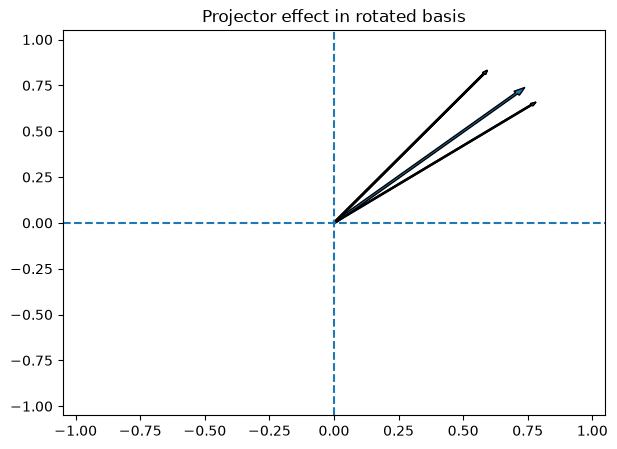

In [6]:
def projector_plus_general_chebyshev_degree(n, A, b):
    evals, evecs = eigh_hermitian(A)
    coeffs = evecs.T @ b
    P_vals = chebyshev_t(n, evals)
    proj_factors = 0.5 * (1.0 + P_vals)
    coeffs_out = proj_factors * coeffs
    return evecs @ coeffs_out


b2 = np.array([1.0, 1.0], dtype=float)

plt.figure(figsize=(7, 5))

b2n = b2 / np.linalg.norm(b2)
plt.arrow(0, 0, b2n[0], b2n[1], width=0.01)

for n in [1, 3, 5, 7, 9]:
    out = projector_plus_general_chebyshev_degree(n, A, b2)
    outn = out / np.linalg.norm(out)
    plt.arrow(0, 0, outn[0], outn[1], width=0.005)

plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Projector effect in rotated basis")
plt.show()

## 4. Using spectral helpers directly

In [7]:
Pi_plus = positive_projector_from_sign(A)
Pi_minus = negative_projector_from_sign(A)

print("Positive projector:")
print(np.round(Pi_plus, 6))

print("\nNegative projector:")
print(np.round(Pi_minus, 6))

Positive projector:
[[ 0.415016 -0.492725]
 [-0.492725  0.584984]]

Negative projector:
[[0.584984 0.492725]
 [0.492725 0.415016]]


## Summary

sign-like polynomials produce spectral filters

projectors arise naturally from sign(A)

QSVT implements these polynomial spectral transforms

## Validation

Compact checks for the expected tutorial behavior.


In [8]:
assert polynomial_parity(poly_T3) == "odd"
assert is_bounded_on_interval(poly_T3)
assert np.allclose(Pi_plus @ Pi_plus, Pi_plus, atol=1e-10)
assert np.allclose(Pi_minus @ Pi_minus, Pi_minus, atol=1e-10)
assert np.allclose(Pi_plus + Pi_minus, np.eye(Pi_plus.shape[0]), atol=1e-10)

print(
    f"projector_completeness_error: {np.max(np.abs(Pi_plus + Pi_minus - np.eye(Pi_plus.shape[0]))):.3e}"
)
print(f"positive_projector_trace [states]: {np.trace(Pi_plus):.6f}")
print("validation: passed")

projector_completeness_error: 0.000e+00
positive_projector_trace [states]: 1.000000
validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to construct sign approximations and spectral projectors.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [previous](06_QSVT_Matrix_Functions_Powers_and_Roots.ipynb) · [next](08_QSVT_Design_and_Presets.ipynb).
